<a href="https://colab.research.google.com/github/tkouncar12/MidtermML/blob/main/MidtermMiniWorkshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, we are generating our predictive maintenance dataset with 1,000 vehicles, looking at engine temperature, vibration, and fluid pressure.

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- 1. DATA HANDLING & GENERATION ---
# np.random.seed(42) acts as a "save point" for randomness.
# It ensures that every time we run this code, we get the exact same
# "random" sensor values so our results are reproducible for the class.
np.random.seed(42)
n_samples = 1000

# Generating 3 types of sensor data for our 1,000 vehicles
engine_temp = np.random.normal(90, 15, n_samples)  # Mean temp 90°C
vibration = np.random.normal(5, 3, n_samples)      # Mean vibration 5Hz
fluid_pressure = np.random.normal(30, 5, n_samples)# Mean pressure 30 PSI

# Defining our 'Ground Truth': Failure happens IF Temp > 105 AND Vibration > 7
# .astype(int) converts True/False to 1 (Failure) or 0 (Healthy)
failure = ((engine_temp > 105) & (vibration > 7)).astype(int)

# Organizing our raw data into a structured DataFrame for the ML tools
df = pd.DataFrame({
    'Temperature': engine_temp,
    'Vibration': vibration,
    'Pressure': fluid_pressure,
    'Failure': failure
})

# --- 2. ML PIPELINE INTEGRATION: DATA SPLITTING ---
# X = The 'Sensors' (Features the model learns from)
# y = The 'Failure' (The target we want to predict)
X = df[['Temperature', 'Vibration', 'Pressure']]
y = df['Failure']

# Split: 80% for training the 'brains', 20% for testing the model's accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully generated and split!")

Data successfully generated and split!


Now for our first tool: Bagging. We are using Random Forest. This algorithm is building 100 independent decision trees in parallel. It gives each tree a random subset of our training data, and then it takes a majority vote to predict if the vehicle will fail.

--- BAGGING: RANDOM FOREST ---
Bagging Accuracy: 99.50%



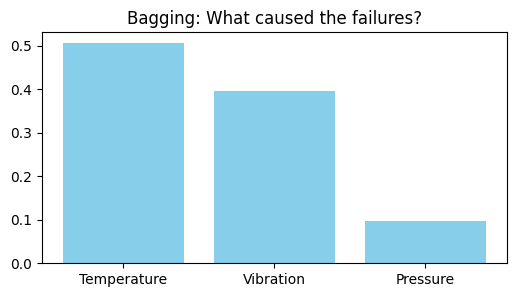

In [9]:
# --- BAGGING WORKSHOP ---
print("--- BAGGING: RANDOM FOREST ---")

# 1. Instantiate and Train
#n_estimators=100: This is the hyperparameter that tells the algorithm exactly how many decision trees to build.
#.fit(X_train, y_train): This is the "learning" step. The model looks at the 800 training sensors (X_train) and the 800 answers (y_train)
#and adjusts its internal math until it finds the patterns, like when temp goes up, failures go up
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict and Interpret Results
#Now we open the vault and test the model on the 200 vehicles it has never seen before.
rf_predictions = rf_model.predict(X_test)
print(f"Bagging Accuracy: {accuracy_score(y_test, rf_predictions) * 100:.2f}%\n")

# 3. Visualize Feature Importance
#During the .fit() stage, the algorithms track which data columns were mathematically most useful for splitting the trees and reducing errors.
#This variable stores those final scores as decimals (e.g., Temperature = 0.5, Vibration = 0.4, Pressure = 0.1). plt.bar simply takes those numbers and draws the visual bar chart for the audience.
plt.figure(figsize=(6, 3))
plt.bar(X.columns, rf_model.feature_importances_, color='skyblue')
plt.title('Bagging: What caused the failures?')
plt.show()

Now let's look at Boosting using XGBoost. Instead of building trees in parallel, this builds 100 trees sequentially. If tree number 1 misclassifies a vehicle failure, tree number 2 specifically focuses on fixing that exact error. Let's run it and see how it interprets the results.

--- BOOSTING: XGBOOST ---
Boosting Accuracy: 99.50%



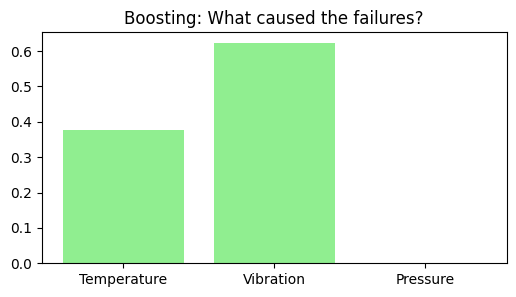

In [10]:
# --- BOOSTING WORKSHOP ---
print("--- BOOSTING: XGBOOST ---")
#Unlike Random Forest, which is built directly into the standard scikit-learn library, XGBoost (Extreme Gradient Boosting) is its own standalone library.
#It was specifically engineered for extreme computational speed and performance, making it a heavy favorite for tabular data competitions and enterprise AI.

# 1. Instantiate and Train
#In Random Forest, this meant "build 100 trees at the exact same time." In XGBoost, this means "perform 100 sequential rounds of learning.
#The Process: It builds Tree 1. Tree 1 will inevitably get some predictions wrong. Tree 2 is then built solely to predict the errors (residuals) of Tree 1.
#Tree 3 is built to fix the errors of Tree 2. It repeats this 100 times, taking tiny, calculated steps toward the perfect answer.

xgb_model = XGBClassifier(n_estimators=100, random_state=42)

#When you call .fit() here, XGBoost looks at the training data and calculates the gradient of the loss function (hence Gradient Boosting).
#In plain English: it mathematically scores how "wrong" the current tree is.
#If the model keeps missing the fact that a truck failed when the vibration spiked, it assigns a massive mathematical "weight" to those specific failure rows.
#The next tree in the sequence is essentially forced to pay attention to that high-vibration data until it gets it right.
xgb_model.fit(X_train, y_train)

# 2. Predict and Interpret Results

#When you pass the 200 unseen vehicles into the model, it doesn't just take a simple majority vote like Random Forest.
#It takes a weighted sum of the predictions from all 100 trees. Trees that were highly accurate during training get more say in the final prediction than the weaker trees.
xgb_predictions = xgb_model.predict(X_test)
print(f"Boosting Accuracy: {accuracy_score(y_test, xgb_predictions) * 100:.2f}%\n")

# 3. Visualize Feature Importance
plt.figure(figsize=(6, 3))

#In Random Forest, the Pressure sensor got a little bit of importance because some random trees were forced to use it. XGBoost doesn't do random subsets of features by default in the same way.
#It evaluates every feature based on how much it reduces the overall error (the "gain")

#When XGBoost looked at Pressure, the math clearly showed that splitting the data based on pressure didn't fix any errors or improve the accuracy. So, it ruthlessly discarded it, scoring it a hard 0.0.
#This is why Boosting is so incredibly useful for the predictive maintenance datasets: it aggressively filters out the noise so you know exactly which sensors actually matter.
plt.bar(X.columns, xgb_model.feature_importances_, color='lightgreen')
plt.title('Boosting: What caused the failures?')
plt.show()

We just ran both our Bagging model (Random Forest) and our Boosting model (XGBoost) on the exact same dataset. As you can see, both models achieved an identical, highly accurate score of 99.50%.

However, the real insight comes from looking at how they achieved that score. We can see exactly how their architectures differ by looking at these Feature Importance charts.

Let's look at the Bagging chart first. Notice how the importance is spread out, and even the Pressure sensor got about 10% of the credit. Why? Because Bagging builds trees completely independently using random subsets of data. Some of those 100 trees didn't even get to look at the Temperature or Vibration columns, so they had to make their best guess using Pressure. When the model averaged all 100 trees together at the end, that little bit of noise got blended into the final result.

Now, look at the Boosting chart. It is a completely different story. The Pressure variable is sitting at absolute zero. Why? Because Boosting builds trees sequentially to ruthlessly correct errors. The algorithm very quickly realized that Pressure had mathematically nothing to do with the engine failures. It aggressively cut out the noise and put 100% of the weight on the features that actually mattered.

CONCLUSION: This perfectly highlights the architectural differences we discussed earlier. Bagging is fantastic for creating a stable, averaged-out model to reduce variance. Boosting is highly aggressive at hunting down errors and ignoring irrelevant data to reduce bias. In a real-world scenario, the Boosting model gives us a much clearer, distraction-free directive on exactly which sensors are causing the breakdowns.